# Binäre Klassifikation: Werkzeugbruch mit logistischer Regression 

**Modellklasse:** binäre multivariate logistische Regression  
**Ohne Verwendung von `sklearn`**: Training, Skalierung, Metriken, Threshold-Tuning und Vorhersagefunktion sind manuell mit `numpy`/`pandas` implementiert.

Ziel: Vorhersage von `tool_breakage` aus `depth_of_cut`, `feed_rate`, `tool_wear_min`.

In [ ]:
# Standardbibliotheken laden, die wir für die manuelle logistische Regression nutzen.
# numpy für numerische Berechnungen, pandas für tabellarische Daten und matplotlib für Visualisierungen.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pfad zur Trainingsdatei, Zielvariable und die drei Ausgangsfeatures.
# Diese Konstanten bleiben im gesamten Notebook unverändert.
DATA_PATH = "werkzeugbruch_training.csv"
TARGET = "tool_breakage"
BASE_FEATURES = ["depth_of_cut", "feed_rate", "tool_wear_min"]

# Reaktive Pandas-Warnungen für Chained Assignment deaktivieren.
pd.options.mode.chained_assignment = None

# Zufallsstart festlegen für reproduzierbare Splits und zufällige Operationen.
np.random.seed(42)

## 1. Daten laden

In [ ]:
# Daten einlesen und Grundinformationen ausgeben.
# Die Datei muss sich im selben Verzeichnis befinden oder der Pfad muss angepasst werden.
df = pd.read_csv(DATA_PATH)

# Kopf der Tabelle, um ein Gefühl für die Spalten und ersten Werte zu bekommen.
print(df.head())
print("\nShape:", df.shape)
print("\nSpalten:", df.columns.tolist())
print("\nFehlende Werte:")
print(df.isna().sum())

# Statistische Kennzahlen zu den numerischen Spalten anzeigen.
df.describe()

   depth_of_cut  feed_rate  tool_wear_min  tool_breakage
0          1.22      0.191           66.7              0
1          3.46      0.254          102.8              0
2          3.23      0.183           22.8              0
3          2.89      0.280           73.4              0
4          1.62      0.314           31.5              0

Shape: (5000, 4)

Spalten: ['depth_of_cut', 'feed_rate', 'tool_wear_min', 'tool_breakage']

Fehlende Werte:
depth_of_cut     0
feed_rate        0
tool_wear_min    0
tool_breakage    0
dtype: int64


,depth_of_cut,feed_rate,tool_wear_min,tool_breakage
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,2.242140,0.278035,58.950020,0.052400
std,1.180713,0.155624,34.687123,0.222855
min,0.500000,0.050000,0.000000,0.000000
25%,1.270000,0.143000,28.400000,0.000000
50%,2.040000,0.251000,58.900000,0.000000
75%,3.072500,0.403000,88.600000,0.000000
max,4.990000,0.600000,120.000000,1.000000


## 2. Explorative Datenanalyse 

Untersucht werden Feature-Verteilungen, Klassenungleichgewicht und Zusammenhänge zwischen Prozessparametern und Werkzeugbruch.

tool_breakage
0    4738
1     262
Name: count, dtype: int64
Bruchrate: 5.24%


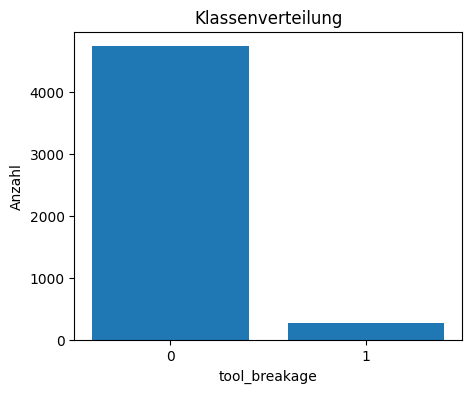

In [ ]:
# Untersuchung der Klassenverteilung in der Zielvariable.
# Bei binären Klassifikationsproblemen ist das Klassenungleichgewicht oft entscheidend.
class_counts = df[TARGET].value_counts().sort_index()
breakage_rate = df[TARGET].mean()#Da die Zielvariable binär ist (0 = kein Bruch, 1 = Bruch), entspricht der Mittelwert direkt dem Anteil der Brüche.
print(class_counts)
print(f"Bruchrate: {breakage_rate:.2%}")

# Balkendiagramm zur Visualisierung der Häufigkeiten der Klassen 0 und 1.
plt.figure(figsize=(5, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.xlabel("tool_breakage")
plt.ylabel("Anzahl")
plt.title("Klassenverteilung")
plt.show()

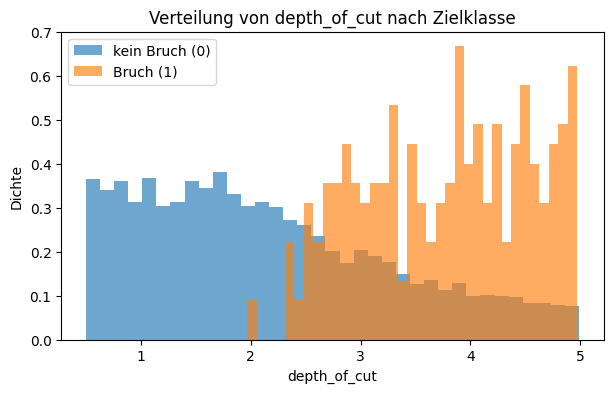

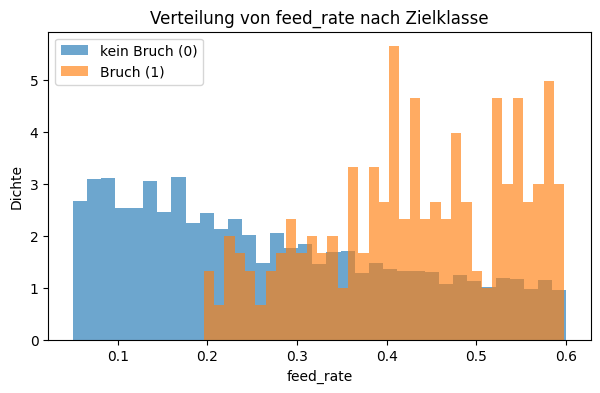

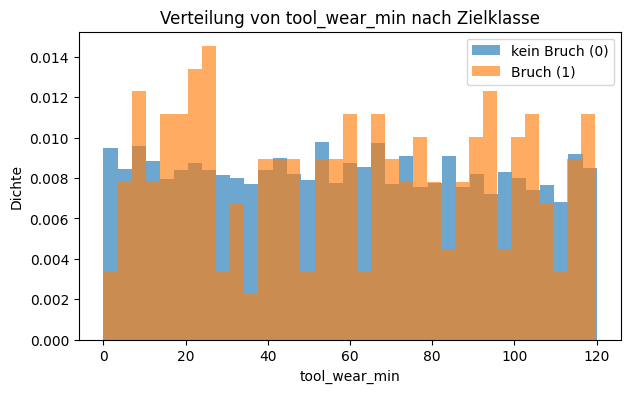

In [ ]:
# Jede Ausgangsgröße einzeln betrachten, getrennt nach Zielklasse 0 vs. 1.
# Dichte-Plots zeigen, ob sich die Verteilungen der Features in den Klassen unterscheiden.
for col in BASE_FEATURES:#Die Schleife durchläuft nacheinander jedes Feature.
    plt.figure(figsize=(7, 4))
    #wählt alle Werte des aktuellen Features aus, bei denen kein Werkzeugbruch aufgetreten ist.
    plt.hist(df.loc[df[TARGET] == 0, col], bins=35, alpha=0.65, label="kein Bruch (0)", density=True)
    plt.hist(df.loc[df[TARGET] == 1, col], bins=35, alpha=0.65, label="Bruch (1)", density=True)
    plt.xlabel(col)
    plt.ylabel("Dichte")
    plt.title(f"Verteilung von {col} nach Zielklasse")
    plt.legend()
    plt.show()

               depth_of_cut  feed_rate  tool_wear_min  tool_breakage
depth_of_cut       1.000000  -0.346077      -0.022064       0.303647
feed_rate         -0.346077   1.000000      -0.013943       0.231938
tool_wear_min     -0.022064  -0.013943       1.000000       0.004347
tool_breakage      0.303647   0.231938       0.004347       1.000000


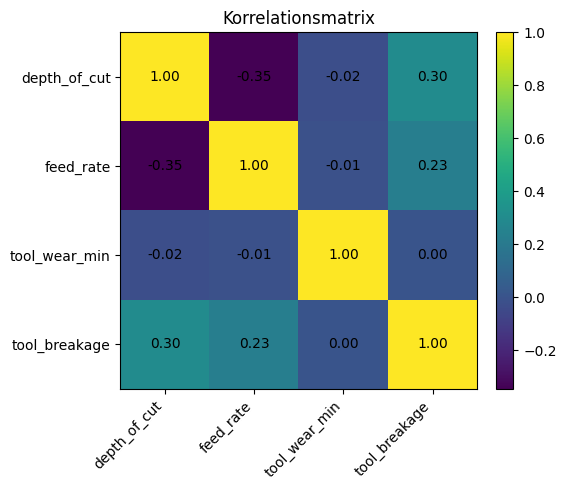

In [ ]:
# Korrelationsanalyse zwischen den Ausgangsfeatures und dem Ziel.
# Diese Informationen helfen zu verstehen, welche Features linear miteinander zusammenhängen.
corr = df[BASE_FEATURES + [TARGET]].corr(numeric_only=True)
#Zunächst wird die Korrelationsmatrix berechnet.
print(corr)
#+1 → perfekter positiver Zusammenhang
#0 → kein linearer Zusammenhang
#−1 → perfekter negativer Zusammenhang
# Heatmap zur Visualisierung der Korrelationsmatrix.
plt.figure(figsize=(6, 5))
im = plt.imshow(corr.values)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Korrelationsmatrix")
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

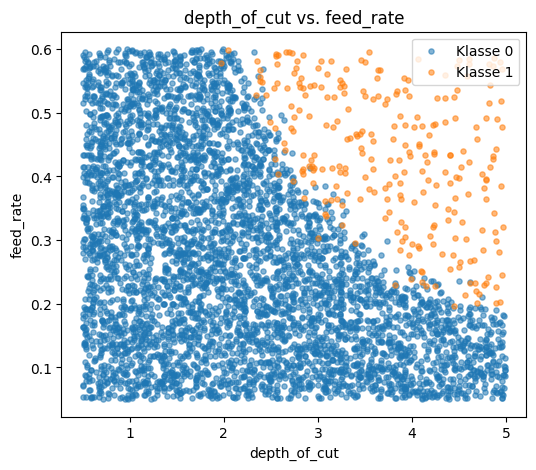

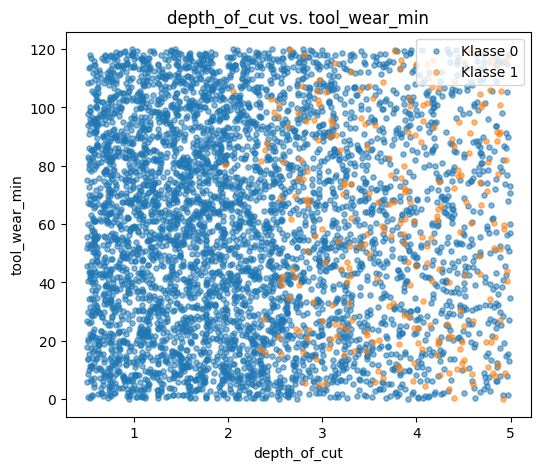

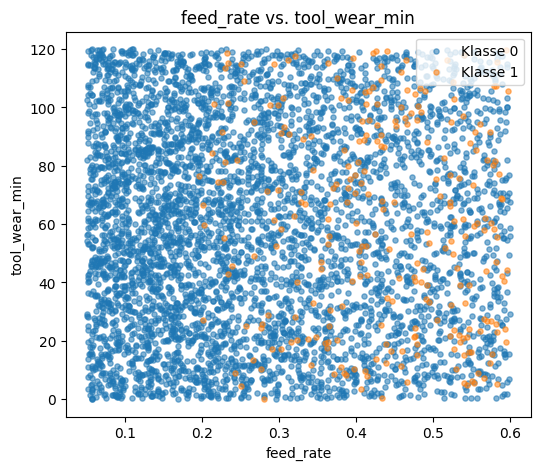

In [ ]:
# Streudiagramme für die Feature-Paare im Originalraum.
# Diese Visualisierung zeigt, wie gut die Klassen 0 und 1 in den einzelnen Feature-Projektionen trennbar sind.
pairs = [("depth_of_cut", "feed_rate"), ("depth_of_cut", "tool_wear_min"), ("feed_rate", "tool_wear_min")]
for xcol, ycol in pairs:
    plt.figure(figsize=(6, 5))
    for cls in [0, 1]:
        part = df[df[TARGET] == cls]
        plt.scatter(part[xcol], part[ycol], s=14, alpha=0.55, label=f"Klasse {cls}")
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.title(f"{xcol} vs. {ycol}")
    plt.legend()
    plt.show()

## 3. Feature Engineering

Logistische Regression ist linear im transformierten Feature-Raum. Da Werkzeugbruch plausibel durch kombinierte Belastung entsteht, werden zusätzlich Interaktions- und quadratische Terme gebildet:

- `depth_of_cut * feed_rate`: Spanungs-/Belastungsindikator
- Produkte mit `tool_wear_min`: Verschleiß verstärkt die Wirkung hoher Prozesslast
- Quadratische Terme: einfache nichtlineare Effekte, ohne die Modellklasse zu verlassen

Das Modell bleibt eine binäre multivariate logistische Regression, aber auf erweiterten Features.

In [ ]:
def make_features(X_df):
    """Erstellt erweiterte Features aus den Originalspalten.

    Eingabe: DataFrame mit den Spalten depth_of_cut, feed_rate, tool_wear_min.
    Ausgabe: NumPy-Array mit den erzeugten transformierten Features.
    """
    d = X_df["depth_of_cut"].to_numpy(dtype=float)
    f = X_df["feed_rate"].to_numpy(dtype=float)
    w = X_df["tool_wear_min"].to_numpy(dtype=float)

    # Kombinationen und quadratische Terme für nichtlineare Zusammenhänge.
    return np.column_stack([#Alle Features werden nebeneinander zu einer Matrix zusammengesetzt.
        d,
        f,
        w,
        d * f,
        d * w,
        f * w,
        d * f * w,
        w ** 2,#quadratischer Term für tool_wear_min, um nichtlineare Effekte zu erfassen.
        d ** 2,#Kleine Schnitttiefen sind unkritisch, große Schnitttiefen erhöhen das Risiko stark.
        f ** 2,#quadratischer Term für feed_rate, um nichtlineare Effekte zu erfassen.
    ])

# Namen der erweiterten Features, um spätere Interpretation zu erleichtern.
ENGINEERED_FEATURE_NAMES = [
    "depth_of_cut",
    "feed_rate",
    "tool_wear_min",
    "depth_x_feed",
    "depth_x_wear",
    "feed_x_wear",
    "depth_x_feed_x_wear",
    "wear_sq",
    "depth_sq",
    "feed_sq",
]
#Dieser Code dient dazu, die neu erzeugten Features zu überprüfen und sicherzustellen, dass das Feature Engineering korrekt funktioniert.
X_eng = make_features(df[BASE_FEATURES])
print(pd.DataFrame(X_eng, columns=ENGINEERED_FEATURE_NAMES).head())

   depth_of_cut  feed_rate  tool_wear_min  depth_x_feed  depth_x_wear  \
0          1.22      0.191           66.7       0.23302        81.374   
1          3.46      0.254          102.8       0.87884       355.688   
2          3.23      0.183           22.8       0.59109        73.644   
3          2.89      0.280           73.4       0.80920       212.126   
4          1.62      0.314           31.5       0.50868        51.030   

   feed_x_wear  depth_x_feed_x_wear   wear_sq  depth_sq   feed_sq  
0      12.7397            15.542434   4448.89    1.4884  0.036481  
1      26.1112            90.344752  10567.84   11.9716  0.064516  
2       4.1724            13.476852    519.84   10.4329  0.033489  
3      20.5520            59.395280   5387.56    8.3521  0.078400  
4       9.8910            16.023420    992.25    2.6244  0.098596  


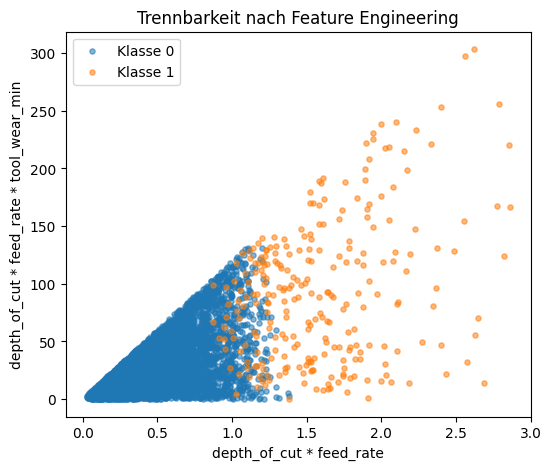

In [ ]:
# Visualisierung der neuen Feature-Kombinationen nach Zielklasse.
# Wir zeigen, ob die Kombination tieferer, interaktiver Features die Klassen besser trennt.
plot_df = pd.DataFrame(X_eng, columns=ENGINEERED_FEATURE_NAMES)
plot_df[TARGET] = df[TARGET].values

plt.figure(figsize=(6, 5))
for cls in [0, 1]:
    part = plot_df[plot_df[TARGET] == cls]
    plt.scatter(part["depth_x_feed"], part["depth_x_feed_x_wear"], s=14, alpha=0.55, label=f"Klasse {cls}")
plt.xlabel("depth_of_cut * feed_rate")
plt.ylabel("depth_of_cut * feed_rate * tool_wear_min")
plt.title("Trennbarkeit nach Feature Engineering")
plt.legend()
plt.show()

## 4. Train/Validation-Split, Skalierung und Hilfsfunktionen

Die Skalierung wird manuell auf dem Trainingsdatensatz gelernt und anschließend auf Validierung und spätere Testdaten angewendet.

In [ ]:
def train_val_split(df, val_fraction=0.2, seed=42):
    """Teilt den Datensatz zufällig in Trainings- und Validierungsdaten auf."""
    rng = np.random.default_rng(seed)
    indices = np.arange(len(df))
    rng.shuffle(indices)
    n_val = int(round(val_fraction * len(df)))
    val_idx = indices[:n_val]
    train_idx = indices[n_val:]
    return df.iloc[train_idx].reset_index(drop=True), df.iloc[val_idx].reset_index(drop=True)

# Splitten des Datensatzes auf Basis des Original-DataFrames.
train_df, val_df = train_val_split(df, val_fraction=0.2, seed=42)

# Feature Engineering jeweils auf Trainings- und Validierungsdaten anwenden.
X_train_raw = make_features(train_df[BASE_FEATURES])
y_train = train_df[TARGET].to_numpy(dtype=float)
X_val_raw = make_features(val_df[BASE_FEATURES])
y_val = val_df[TARGET].to_numpy(dtype=float)

# Skalierung: Mittelwert und Standardabweichung werden nur aus dem Training berechnet.
feature_mean = X_train_raw.mean(axis=0)
feature_std = X_train_raw.std(axis=0)
feature_std[feature_std == 0] = 1.0

def standardize(X):
    """Standardisiert die Features anhand der Trainingsstatistiken."""
    return (X - feature_mean) / feature_std

X_train = standardize(X_train_raw)
X_val = standardize(X_val_raw)

# Ausgabe der Dimensionen und der Klassenverteilung im Split.
print("Positive Klasse train:", int(y_train.sum()), "von", len(y_train))
print("Positive Klasse valid:", int(y_val.sum()), "von", len(y_val))
print("Train:", X_train.shape, "Validierung:", X_val.shape)

Train: (4000, 10) Validierung: (1000, 10)
Positive Klasse train: 204 von 4000
Positive Klasse valid: 58 von 1000


In [ ]:
def sigmoid(z):
    """Logistische Sigmoid-Funktion zur Berechnung von Wahrscheinlichkeiten."""
    # Numerische Stabilisierung: Verhindere Overflow bei sehr großen Beträgen.
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def add_intercept(X):
    """Fügt jedem Beispiel eine Konstante 1 als Bias-Feature hinzu."""
    return np.column_stack([np.ones(X.shape[0]), X])

def precision_recall_f1(y_true, y_pred):
    """Berechnet Performance-Kennzahlen für binäre Vorhersagen."""
    y_true = y_true.astype(int)
    y_pred = y_pred.astype(int)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {"tp": tp, "fp": fp, "fn": fn, "tn": tn, "precision": precision, "recall": recall, "f1": f1}

def tune_threshold(y_true, proba, thresholds=None):
    """Findet den Threshold mit dem höchsten F1-Score auf Validierungsdaten."""
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)
    rows = []
    best = None
    for t in thresholds:
        pred = (proba >= t).astype(int)
        m = precision_recall_f1(y_true, pred)
        row = {"threshold": t, **m}
        rows.append(row)
        if best is None or row["f1"] > best["f1"]:
            best = row
    return best, pd.DataFrame(rows)

## 5. Logistische Regression ohne sklearn trainieren

Wegen des Klassenungleichgewichts wird eine gewichtete Binary-Cross-Entropy optimiert. Die positive Klasse erhält ein höheres Gewicht.

In [ ]:
def train_logistic_regression(
    X, y, learning_rate=0.03, n_iter=30000, l2=0.005, class_weight="balanced", verbose=True
):
    """Trainiert eine logistische Regression per Gradientenabstieg."""
    X_i = add_intercept(X)
    n_samples, n_features = X_i.shape
    beta = np.zeros(n_features)

    # Bei unbalancierten Klassen gewichten wir die positive und negative Klasse so,
    # dass sie ungefähr gleich viel Einfluss auf den Verlust haben.
    if class_weight == "balanced":
        n_pos = np.sum(y == 1)
        n_neg = np.sum(y == 0)
        sample_weight = np.where(y == 1, n_samples / (2 * n_pos), n_samples / (2 * n_neg))
    else:
        sample_weight = np.ones(n_samples)

    losses = []
    for it in range(n_iter):
        # Lineare Vorhersage im erweiterten Feature-Raum.
        z = X_i @ beta
        p = sigmoid(z)

        # Binary Cross Entropy mit Stabilisierung gegen log(0).
        eps = 1e-12
        bce = -sample_weight * (y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
        loss = bce.mean() + 0.5 * l2 * np.sum(beta[1:] ** 2)
        losses.append(loss)

        # Gradientenberechnung mit Regularisierung für die Koeffizienten (ohne Bias).
        grad = (X_i.T @ ((p - y) * sample_weight)) / n_samples
        grad[1:] += l2 * beta[1:]
        beta -= learning_rate * grad

        if verbose and it % 5000 == 0:
            print(f"Iteration {it:5d} | Loss = {loss:.5f}")

    return beta, np.array(losses)

# Modell trainieren und die gelernten Parameter ausgeben.
beta, losses = train_logistic_regression(X_train, y_train)
intercept_ = beta[0]
coef_ = beta[1:]

print("\nintercept_:", intercept_)
print("coef_:")
for name, c in zip(ENGINEERED_FEATURE_NAMES, coef_):
    print(f"{name:25s} {c: .6f}")

Iteration     0 | Loss = 0.69315
Iteration  5000 | Loss = 0.10966
Iteration 10000 | Loss = 0.10432
Iteration 15000 | Loss = 0.10317
Iteration 20000 | Loss = 0.10285
Iteration 25000 | Loss = 0.10274

intercept_: -5.5854974832039215
coef_:
depth_of_cut               0.854162
feed_rate                  0.492886
tool_wear_min             -0.399242
depth_x_feed               2.602170
depth_x_wear               0.180552
feed_x_wear               -0.123134
depth_x_feed_x_wear        1.198517
wear_sq                   -0.659093
depth_sq                   0.666403
feed_sq                    0.022755


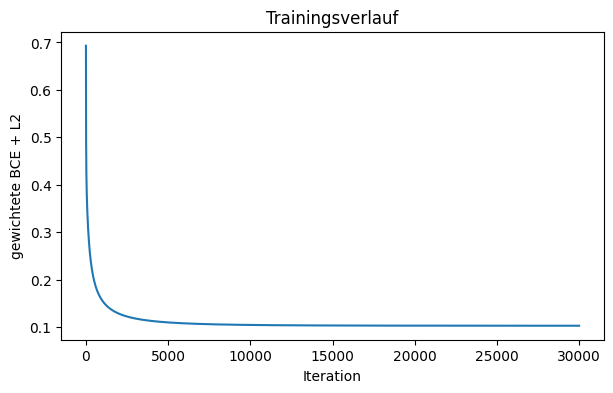

In [ ]:
# Visualisierung des Trainingsverlaufs über die Iterationen.
# Dadurch sehen wir, ob der Verlust stabil sinkt und ob der Lernprozess konvergiert.
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("gewichtete BCE + L2")
plt.title("Trainingsverlauf")
plt.show()

## 6. Evaluation und Threshold-Tuning

Threshold 0.50 Validierung: {'tp': np.int64(57), 'fp': np.int64(32), 'fn': np.int64(1), 'tn': np.int64(910), 'precision': np.float64(0.6404494382022472), 'recall': np.float64(0.9827586206896551), 'f1': np.float64(0.7755102040816326)}

Bester Threshold auf Validierung:
{'threshold': np.float64(0.8), 'tp': np.int64(52), 'fp': np.int64(2), 'fn': np.int64(6), 'tn': np.int64(940), 'precision': np.float64(0.9629629629629629), 'recall': np.float64(0.896551724137931), 'f1': np.float64(0.9285714285714286)}


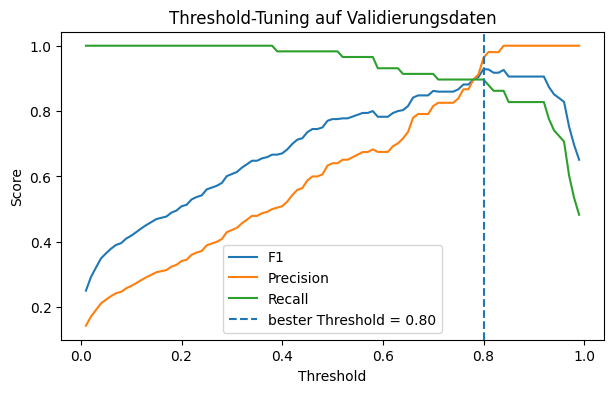

In [ ]:
# Wahrscheinlichkeiten für Training und Validierung berechnen.
train_proba = sigmoid(add_intercept(X_train) @ beta)
val_proba = sigmoid(add_intercept(X_val) @ beta)

# Standard-Threshold 0.5 als Referenz betrachten.
for t in [0.5]:
    print(f"Threshold {t:.2f} Validierung:", precision_recall_f1(y_val, (val_proba >= t).astype(int)))

# Optimale Schwelle nach F1 auf den Validierungsdaten suchen.
best_threshold_info, threshold_table = tune_threshold(y_val, val_proba)
FINAL_THRESHOLD = float(best_threshold_info["threshold"])

print("\nBester Threshold auf Validierung:")
print(best_threshold_info)

# Plot der F1-, Precision- und Recall-Kurven als Funktion des Thresholds.
plt.figure(figsize=(7, 4))
plt.plot(threshold_table["threshold"], threshold_table["f1"], label="F1")
plt.plot(threshold_table["threshold"], threshold_table["precision"], label="Precision")
plt.plot(threshold_table["threshold"], threshold_table["recall"], label="Recall")
plt.axvline(FINAL_THRESHOLD, linestyle="--", label=f"bester Threshold = {FINAL_THRESHOLD:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold-Tuning auf Validierungsdaten")
plt.legend()
plt.show()

Finale Validierungsmetriken:
{'tp': np.int64(52), 'fp': np.int64(2), 'fn': np.int64(6), 'tn': np.int64(940), 'precision': np.float64(0.9629629629629629), 'recall': np.float64(0.896551724137931), 'f1': np.float64(0.9285714285714286)}


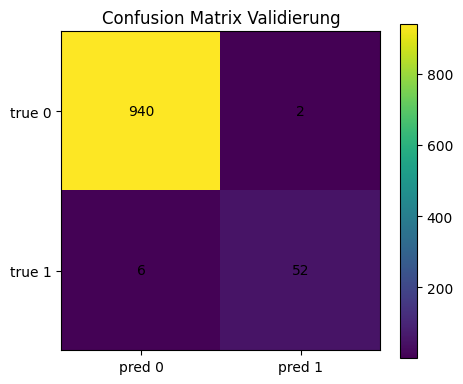

In [ ]:
# Vorhersagen mit dem finalen Threshold erzeugen und auswerten.
final_val_pred = (val_proba >= FINAL_THRESHOLD).astype(int)
metrics = precision_recall_f1(y_val, final_val_pred)
print("Finale Validierungsmetriken:")
print(metrics)

# Verwirrungsmatrix zur Beurteilung von True/False Positives/Negatives.
cm = np.array([[metrics["tn"], metrics["fp"]], [metrics["fn"], metrics["tp"]]])
plt.figure(figsize=(4.8, 4))
plt.imshow(cm)
plt.xticks([0, 1], ["pred 0", "pred 1"])
plt.yticks([0, 1], ["true 0", "true 1"])
plt.title("Confusion Matrix Validierung")
plt.colorbar()
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()

## 7. Finale Vorhersagefunktion `predict_breakage(X)`

Diese Funktion akzeptiert einen beliebigen Original-DataFrame **ohne Zielvariable** mit den drei Originalspalten und gibt ein NumPy-Array mit 0/1-Vorhersagen zurück.

In [ ]:
def predict_breakage_proba(X):
    """Berechnet die Bruchwahrscheinlichkeit für neue Beispiele."""
    X_raw = make_features(X[BASE_FEATURES])
    X_scaled = standardize(X_raw)
    return sigmoid(add_intercept(X_scaled) @ beta)

def predict_breakage(X):
    """Gibt 0/1-Vorhersagen zurück, basierend auf dem finalen Threshold."""
    proba = predict_breakage_proba(X)
    return (proba >= FINAL_THRESHOLD).astype(int)

# Signaturtest: Die Funktion muss ein NumPy-Array mit 0/1 liefern.

test_pred = predict_breakage(val_df[BASE_FEATURES].head())
print(type(test_pred), test_pred, test_pred.dtype, test_pred.shape)

<class 'numpy.ndarray'> [0 0 0 0 0] int64 (5,)


## 8. Koeffizienteninterpretation

Die Koeffizienten beziehen sich auf standardisierte, transformierte Features. Positive Werte erhöhen die Log-Odds für Werkzeugbruch, negative Werte senken sie.

In [ ]:
# Tabelle zur Interpretation der gelernten Koeffizienten.
# abs_coef zeigt, welche Features den größten Einfluss haben, unabhängig von Vorzeichen.
coef_table = pd.DataFrame({
    "feature": ENGINEERED_FEATURE_NAMES,
    "coef": coef_,
    "abs_coef": np.abs(coef_)

}).sort_values("abs_coef", ascending=False)
coef_table

,feature,coef,abs_coef
3,depth_x_feed,2.602170,2.602170
6,depth_x_feed_x_wear,1.198517,1.198517
0,depth_of_cut,0.854162,0.854162
8,depth_sq,0.666403,0.666403
7,wear_sq,-0.659093,0.659093
1,feed_rate,0.492886,0.492886
2,tool_wear_min,-0.399242,0.399242
4,depth_x_wear,0.180552,0.180552
5,feed_x_wear,-0.123134,0.123134
9,feed_sq,0.022755,0.022755


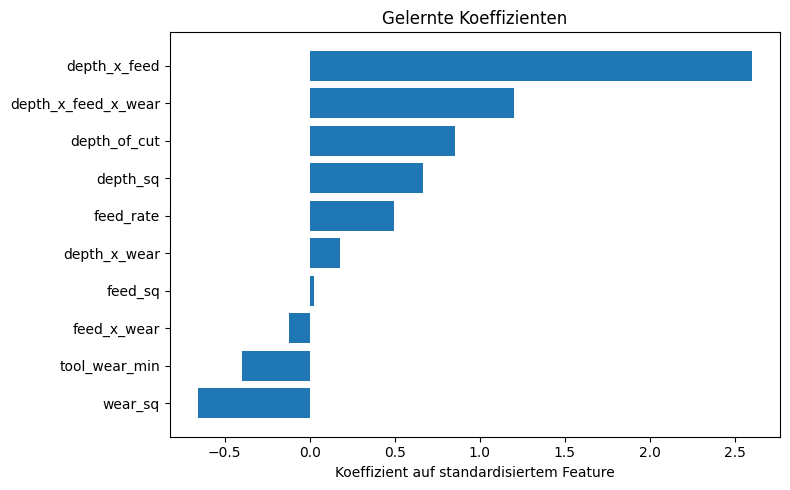

In [ ]:
# Balkendiagramm zur Visualisierung der Richtung und Stärke der Koeffizienten.
plt.figure(figsize=(8, 5))
ordered = coef_table.sort_values("coef")
plt.barh(ordered["feature"], ordered["coef"])
plt.xlabel("Koeffizient auf standardisiertem Feature")
plt.title("Gelernte Koeffizienten")
plt.tight_layout()
plt.show()

**Interpretation:**

- Große positive Koeffizienten zeigen Feature-Kombinationen, die das Bruchrisiko erhöhen. Typischerweise sind Interaktionsterme mit Prozesslast und Verschleiß besonders relevant.
- Ein positiver Koeffizient bei `depth_x_feed` oder `depth_x_feed_x_wear` bedeutet: hohe Schnitttiefe und hoher Vorschub sind besonders kritisch, vor allem bei zunehmender Werkzeugstandzeit.
- Negative Koeffizienten einzelner quadratischer oder Interaktionsterme können durch Korrelationen zwischen den transformierten Features entstehen. Sie sind deshalb nicht isoliert physikalisch zu lesen, sondern im Zusammenspiel des linearen Prädiktors.
- Physikalisch passt das Modell zur Erwartung: Bruch entsteht nicht nur durch einen einzelnen Parameter, sondern durch kombinierte mechanische und verschleißbezogene Belastung.

## 9. Manuelle Implementierung und numerischer Vergleich

Da das Modell vollständig manuell implementiert ist, ist die manuelle Gleichung identisch mit der verwendeten Vorhersage. Der folgende Block zeigt explizit die Berechnung über \(p_i = \sigma(w^T x_i + b)\).

In [ ]:
def manual_predict_proba_from_coef(X_scaled, coef, intercept):
    """Berechnet die Wahrscheinlichkeit aus Koeffizienten und standardisierten Features."""
    z = X_scaled @ coef + intercept
    return sigmoid(z)

# Vergleich zwischen expliziter manueller Berechnung und der Vorhersagefunktion.
manual_val_proba = manual_predict_proba_from_coef(X_val, coef_, intercept_)
model_val_proba = predict_breakage_proba(val_df[BASE_FEATURES])

max_abs_diff = np.max(np.abs(manual_val_proba - model_val_proba))

print("Maximale absolute Abweichung:", max_abs_diff)
assert max_abs_diff < 1e-10

Maximale absolute Abweichung: 3.3306690738754696e-16


## 10. Entscheidungsgrenze im Original-Feature-Raum

Visualisiert wird ein 2D-Schnitt: zwei Features werden variiert, das dritte Feature wird auf den Median gesetzt. Die Grenze ist dadurch im Original-Feature-Raum interpretierbar.

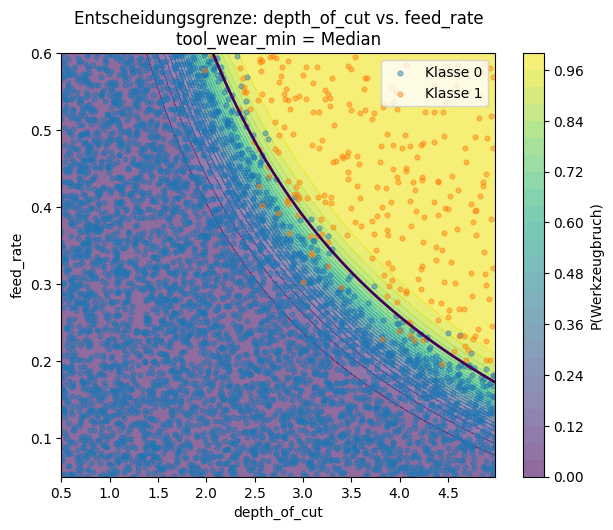

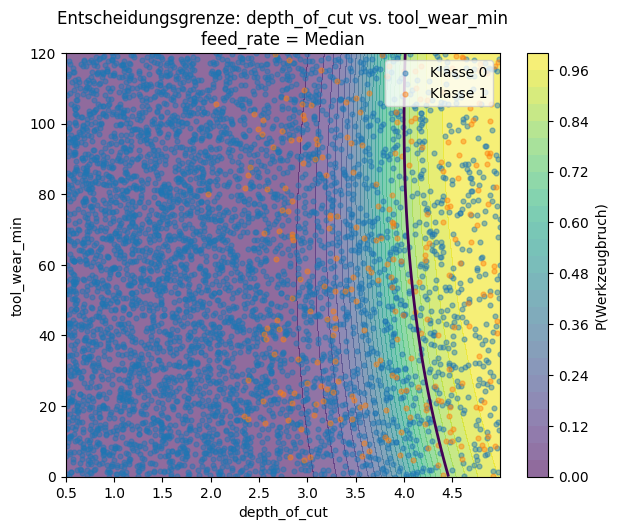

In [ ]:
def plot_decision_boundary_2d(x_feature, y_feature, fixed_feature):
    """Zeigt die Klassengrenze in einem 2D-Schnitt mit festgehaltenem dritten Feature."""
    x_min, x_max = df[x_feature].min(), df[x_feature].max()
    y_min, y_max = df[y_feature].min(), df[y_feature].max()
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 180), np.linspace(y_min, y_max, 180))

    grid = pd.DataFrame({
        x_feature: xx.ravel(),
        y_feature: yy.ravel(),
        fixed_feature: np.full(xx.size, df[fixed_feature].median())
    })
    # Sicherstellen, dass die Spalten in der erwarteten Reihenfolge stehen.
    grid = grid[BASE_FEATURES]
    zz = predict_breakage_proba(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 5.5))
    plt.contourf(xx, yy, zz, levels=25, alpha=0.6)
    plt.colorbar(label="P(Werkzeugbruch)")
    plt.contour(xx, yy, zz, levels=[FINAL_THRESHOLD], linewidths=2)

    for cls in [0, 1]:
        part = df[df[TARGET] == cls]
        plt.scatter(part[x_feature], part[y_feature], s=12, alpha=0.45, label=f"Klasse {cls}")

    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.title(f"Entscheidungsgrenze: {x_feature} vs. {y_feature}\n{fixed_feature} = Median")
    plt.legend()
    plt.show()

# Zwei projizierte 2D-Schnitte darstellen.

plot_decision_boundary_2d("depth_of_cut", "feed_rate", "tool_wear_min")
plot_decision_boundary_2d("depth_of_cut", "tool_wear_min", "feed_rate")

## 11. Kritische Reflexion

- Das Modell ist trotz Feature Engineering nur linear im transformierten Feature-Raum. Sehr komplexe Bruchmechanismen können dadurch nur approximiert werden.
- Die Koeffizienten der Engineering-Features sind wegen Multikollinearität nicht vollständig unabhängig interpretierbar.
- Threshold-Tuning wurde auf einem Validierungssplit durchgeführt; für eine robuste Abschätzung wäre Cross-Validation oder ein separater Testdatensatz besser.
- Bei stark unausgewogenen Klassen hängt der optimale Threshold von den Kosten falscher Alarme und übersehener Brüche ab.
- Die Visualisierung der Entscheidungsgrenze ist nur ein 2D-Schnitt, während das Modell in einem höherdimensionalen transformierten Raum arbeitet.

## 12. Kurzfassung für die Präsentation

1. Problem: Werkzeugbruch ist selten, daher ist Accuracy ungeeignet.
2. EDA: deutliche Klassenimbalance; Bruchrisiko hängt nicht nur von Einzelfeatures ab.
3. Feature Engineering: Interaktionen aus Schnitttiefe, Vorschub und Werkzeugverschleiß verbessern die Trennbarkeit.
4. Modell: gewichtete logistische Regression ohne sklearn.
5. Threshold-Tuning: optimiert F1 der positiven Klasse.
6. Interpretation: kombinierte Prozesslast und Verschleiß treiben die Bruchwahrscheinlichkeit.
7. Grenzen: lineares Modell, begrenzte nichtlineare Struktur, Threshold abhängig vom Anwendungskontext.